# Evaluation of Whisper Models

## 1 Overview

## 2 Importing Libraries

In [1]:
from pathlib import Path
import gc
import re
import time
import numpy as np
import pandas as pd
import torch
from transformers import pipeline
import unicodedata
from datasets import Audio, load_dataset
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 Evaluation Settings and Candidate Models

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 0 if torch.cuda.is_available() else -1

In [3]:
output_folder = Path(
    "outputs/whisper"
)

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Output folder:",
    output_folder
)

Output folder: outputs\whisper


In [4]:
models = {
    "Whisper-Tiny": {
        "model_id": "openai/whisper-tiny",
        "batch_size": 1
    },

    "Whisper-Base": {
        "model_id": "openai/whisper-base",
        "batch_size": 1
    },

    "Whisper-Small": {
        "model_id": "openai/whisper-small",
        "batch_size": 1
    }
}

In [5]:
languages = {
    "English": {
        "fleurs_config": "en_us",
        "whisper_language": "en"
    },

    "Malay": {
        "fleurs_config": "ms_my",
        "whisper_language": "ms"
    },

    "Chinese": {
        "fleurs_config": "cmn_hans_cn",
        "whisper_language": "zh"
    },

    "Tamil": {
        "fleurs_config": "ta_in",
        "whisper_language": "ta"
    }
}

SAMPLES_PER_LANGUAGE = 200

## 4 Load Multilingual FLEURS Dataset

In [6]:
def normalise_text(text):
    text = unicodedata.normalize(
        "NFKC",
        str(text)
    ).lower()

    text = "".join(
        character
        if character.isalnum()
        or character.isspace()
        else " "
        for character in text
    )

    text = " ".join(
        text.split()
    )

    return text.strip()

In [7]:
fleurs_audio_folder = Path(
    "../../data/processed/fleurs_whisper"
)

fleurs_audio_folder.mkdir(
    parents=True,
    exist_ok=True
)


def load_fleurs_split(
    split_name,
    samples_per_language
):
    records = []

    for language_name, language_details in languages.items():
        print(
            f"Loading {language_name} "
            f"{split_name} data..."
        )

        dataset = load_dataset(
            "google/fleurs",
            language_details["fleurs_config"],
            split=split_name
        )

        dataset = dataset.cast_column(
            "audio",
            Audio(decode=False)
        )

        dataset = (
            dataset
            .shuffle(seed=SEED)
            .select(
                range(
                    min(
                        samples_per_language,
                        len(dataset)
                    )
                )
            )
        )

        language_folder = (
            fleurs_audio_folder
            / split_name
            / language_details["fleurs_config"]
        )

        language_folder.mkdir(
            parents=True,
            exist_ok=True
        )

        for index, sample in enumerate(dataset):
            audio_information = sample["audio"]

            original_path = Path(
                audio_information["path"]
            )

            file_suffix = (
                original_path.suffix
                if original_path.suffix
                else ".wav"
            )

            audio_path = (
                language_folder
                / f"{index:04d}{file_suffix}"
            )

            if not audio_path.exists():
                with open(audio_path, "wb") as audio_file:
                    audio_file.write(
                        audio_information["bytes"]
                    )

            records.append({
                "audio_path": audio_path,
                "reference": normalise_text(
                    sample["transcription"]
                ),
                "language": language_name,
                "whisper_language": (
                    language_details[
                        "whisper_language"
                    ]
                )
            })

    return pd.DataFrame(records)

In [8]:
validation_data = load_fleurs_split(
    split_name="validation",
    samples_per_language=SAMPLES_PER_LANGUAGE
)

print(
    "\nTotal validation recordings:",
    len(validation_data)
)

display(
    validation_data[
        [
            "language",
            "audio_path",
            "reference"
        ]
    ].head()
)

display(
    validation_data[
        "language"
    ].value_counts()
)

Loading English validation data...
Loading Malay validation data...
Loading Chinese validation data...
Loading Tamil validation data...

Total validation recordings: 800


,language,audio_path,reference
0,English,..\..\data\processed\fleurs_whisper\validation...,technology offers the solution with virtual fi...
1,English,..\..\data\processed\fleurs_whisper\validation...,there are a lot of social and political effect...
2,English,..\..\data\processed\fleurs_whisper\validation...,the final score was a one point victory 21 to ...
3,English,..\..\data\processed\fleurs_whisper\validation...,inland waterways can be a good theme to base a...
4,English,..\..\data\processed\fleurs_whisper\validation...,out of 1 400 people polled prior to the 2010 f...


language
English    200
Malay      200
Chinese    200
Tamil      200
Name: count, dtype: int64

## 5 Transcription and Multilingual ASR Metrics

In [9]:
def word_error_counts(reference, hypothesis):
    reference_words = normalise_text(
        reference
    ).split()

    hypothesis_words = normalise_text(
        hypothesis
    ).split()

    rows = len(reference_words) + 1
    columns = len(hypothesis_words) + 1

    distance = [
        [0] * columns
        for _ in range(rows)
    ]

    for row in range(rows):
        distance[row][0] = row

    for column in range(columns):
        distance[0][column] = column

    for row in range(1, rows):
        for column in range(1, columns):
            substitution_cost = (
                0
                if reference_words[row - 1]
                == hypothesis_words[column - 1]
                else 1
            )

            distance[row][column] = min(
                distance[row - 1][column] + 1,
                distance[row][column - 1] + 1,
                distance[row - 1][column - 1]
                + substitution_cost
            )

    return (
        distance[-1][-1],
        len(reference_words)
    )

In [10]:
def character_error_counts(reference, hypothesis):
    reference_text = (
        normalise_text(reference)
        .replace(" ", "")
    )

    hypothesis_text = (
        normalise_text(hypothesis)
        .replace(" ", "")
    )

    reference_characters = list(reference_text)
    hypothesis_characters = list(hypothesis_text)

    rows = len(reference_characters) + 1
    columns = len(hypothesis_characters) + 1

    distance = [
        [0] * columns
        for _ in range(rows)
    ]

    for row in range(rows):
        distance[row][0] = row

    for column in range(columns):
        distance[0][column] = column

    for row in range(1, rows):
        for column in range(1, columns):
            substitution_cost = (
                0
                if reference_characters[row - 1]
                == hypothesis_characters[column - 1]
                else 1
            )

            distance[row][column] = min(
                distance[row - 1][column] + 1,
                distance[row][column - 1] + 1,
                distance[row - 1][column - 1]
                + substitution_cost
            )

    return (
        distance[-1][-1],
        len(reference_characters)
    )

In [11]:
def calculate_asr_metrics(
    references,
    transcriptions
):
    total_word_errors = 0
    total_words = 0

    total_character_errors = 0
    total_characters = 0

    exact_matches = 0

    sentence_wers = []
    sentence_cers = []

    for reference, transcription in zip(
        references,
        transcriptions
    ):
        word_errors, words = word_error_counts(
            reference,
            transcription
        )

        character_errors, characters = (
            character_error_counts(
                reference,
                transcription
            )
        )

        total_word_errors += word_errors
        total_words += words

        total_character_errors += (
            character_errors
        )
        total_characters += characters

        sentence_wers.append(
            word_errors / words
            if words
            else 0
        )

        sentence_cers.append(
            character_errors / characters
            if characters
            else 0
        )

        if normalise_text(
            reference
        ) == normalise_text(
            transcription
        ):
            exact_matches += 1

    return {
        "WER": (
            total_word_errors / total_words
            if total_words
            else 0
        ),

        "CER": (
            total_character_errors
            / total_characters
            if total_characters
            else 0
        ),

        "Average Sentence WER": (
            np.mean(sentence_wers)
        ),

        "Average Sentence CER": (
            np.mean(sentence_cers)
        ),

        "Exact Match Accuracy": (
            exact_matches / len(references)
            if references
            else 0
        )
    }

In [12]:
def run_whisper_model(model_details, data):
    model_id = model_details["model_id"]
    batch_size = model_details["batch_size"]

    loading_start = time.perf_counter()

    transcriber = pipeline(
        task="automatic-speech-recognition",
        model=model_id,
        device=device
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    loading_time = (
        time.perf_counter() - loading_start
    )

    transcriptions = [None] * len(data)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    for whisper_language, language_data in data.groupby(
        "whisper_language",
        sort=False
    ):
        print(
            f"  Transcribing language: "
            f"{whisper_language}"
        )

        audio_paths = (
            language_data["audio_path"]
            .astype(str)
            .tolist()
        )

        outputs = transcriber(
            audio_paths,
            batch_size=batch_size,
            return_timestamps=True,
            generate_kwargs={
                "language": whisper_language,
                "task": "transcribe"
            }
        )

        for dataframe_index, output in zip(
            language_data.index,
            outputs
        ):
            position = data.index.get_loc(
                dataframe_index
            )

            transcriptions[position] = (
                normalise_text(
                    output["text"]
                )
            )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - inference_start
    )

    del transcriber

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "transcriptions": transcriptions,
        "loading_time": loading_time,
        "inference_time": inference_time
    }

## 6 Model Evaluation on Validation Data

In [13]:
validation_results = []
validation_language_results = []
validation_transcriptions = {}

for model_name, model_details in models.items():
    print(f"\nEvaluating {model_name}...")

    evaluation = run_whisper_model(
        model_details,
        validation_data
    )

    transcriptions = evaluation[
        "transcriptions"
    ]

    validation_transcriptions[model_name] = (
        transcriptions
    )

    prediction_series = pd.Series(
        transcriptions,
        index=validation_data.index
    )

    language_cers = []
    language_wers = []

    for language_name in languages.keys():

        language_mask = (
            validation_data["language"]
            == language_name
        )

        language_references = (
            validation_data.loc[
                language_mask,
                "reference"
            ]
            .tolist()
        )

        language_predictions = (
            prediction_series.loc[
                language_mask
            ]
            .tolist()
        )

        language_metrics = (
            calculate_asr_metrics(
                language_references,
                language_predictions
            )
        )

        language_cers.append(
            language_metrics["CER"]
        )

        language_wers.append(
            language_metrics["WER"]
        )

        validation_language_results.append({
            "Model": model_name,
            "Language": language_name,
            "WER": language_metrics["WER"],
            "CER": language_metrics["CER"],
            "Average Sentence WER": (
                language_metrics[
                    "Average Sentence WER"
                ]
            ),
            "Average Sentence CER": (
                language_metrics[
                    "Average Sentence CER"
                ]
            ),
            "Exact Match Accuracy": (
                language_metrics[
                    "Exact Match Accuracy"
                ]
            )
        })

        print(
            f"  {language_name}: "
            f"WER={language_metrics['WER']:.4f}, "
            f"CER={language_metrics['CER']:.4f}"
        )

    macro_cer = float(
        np.mean(language_cers)
    )

    macro_wer = float(
        np.mean(language_wers)
    )

    validation_results.append({
        "Model": model_name,
        "Macro WER": macro_wer,
        "Macro CER": macro_cer,
        "Loading Time": (
            evaluation["loading_time"]
        ),
        "Processing Time": (
            evaluation["inference_time"]
        ),
        "ms per Recording": (
            evaluation["inference_time"]
            / len(validation_data)
            * 1000
        )
    })

    print(
        f"  Macro CER: {macro_cer:.4f}"
    )


Evaluating Whisper-Tiny...
  Transcribing language: en
  Transcribing language: ms
  Transcribing language: zh
  Transcribing language: ta
  English: WER=0.1285, CER=0.0578
  Malay: WER=0.9171, CER=0.4795
  Chinese: WER=1.0000, CER=0.3943
  Tamil: WER=2.7593, CER=2.2183
  Macro CER: 0.7875

Evaluating Whisper-Base...
  Transcribing language: en
  Transcribing language: ms
  Transcribing language: zh
  Transcribing language: ta
  English: WER=0.0976, CER=0.0447
  Malay: WER=0.3641, CER=0.1101
  Chinese: WER=1.0000, CER=0.3745
  Tamil: WER=0.8528, CER=0.6358
  Macro CER: 0.2913

Evaluating Whisper-Small...
  Transcribing language: en
  Transcribing language: ms
  Transcribing language: zh
  Transcribing language: ta
  English: WER=0.0648, CER=0.0298
  Malay: WER=0.1951, CER=0.0637
  Chinese: WER=0.9994, CER=0.2145
  Tamil: WER=0.4510, CER=0.3187
  Macro CER: 0.1567


In [14]:
validation_results_df = pd.DataFrame(
    validation_results
)

validation_language_results_df = (
    pd.DataFrame(
        validation_language_results
    )
)

## 7 Comparing and Selecting Best Model

In [15]:
validation_results_df = (
    validation_results_df
    .sort_values(
        by="Macro CER",
        ascending=True
    )
    .reset_index(drop=True)
)

display(validation_results_df)

display(
    validation_language_results_df
)

,Model,Macro WER,Macro CER,Loading Time,Processing Time,ms per Recording
0,Whisper-Small,0.427575,0.156689,3.353601,1289.098742,1611.373428
1,Whisper-Base,0.578630,0.291260,2.783359,753.984734,942.480918
2,Whisper-Tiny,1.201214,0.787472,2.405072,950.626671,1188.283339


,Model,Language,WER,CER,Average Sentence WER,Average Sentence CER,Exact Match Accuracy
0,Whisper-Tiny,English,0.128469,0.057752,0.128622,0.057200,0.28
1,Whisper-Tiny,Malay,0.917091,0.479547,0.918287,0.484511,0.00
2,Whisper-Tiny,Chinese,1.000000,0.394294,1.000000,0.385269,0.00
3,Whisper-Tiny,Tamil,2.759297,2.218297,2.981912,2.393255,0.00
4,Whisper-Base,English,0.097608,0.044673,0.096633,0.043739,0.36
5,Whisper-Base,Malay,0.364100,0.110058,0.368597,0.114146,0.03
6,Whisper-Base,Chinese,1.000000,0.374530,1.000000,0.360023,0.00
7,Whisper-Base,Tamil,0.852812,0.635776,0.920686,0.689313,0.00
8,Whisper-Small,English,0.064833,0.029831,0.063233,0.029012,0.49
9,Whisper-Small,Malay,0.195063,0.063706,0.206928,0.069498,0.10


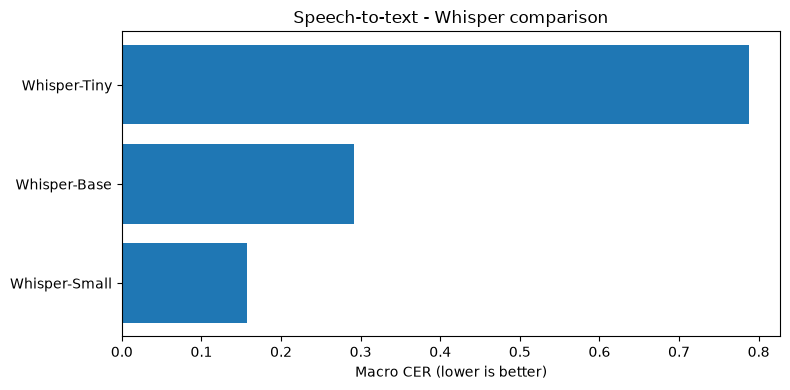

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(validation_results_df["Model"], validation_results_df["Macro CER"])
plt.xlabel("Macro CER (lower is better)")
plt.title("Speech-to-text - Whisper comparison")
plt.tight_layout()
plt.show()

In [17]:
selected_model_name = validation_results_df.loc[
    0,
    "Model"
]

selected_model_details = models[
    selected_model_name
]

print(
    "Selected multilingual Whisper model:",
    selected_model_name
)

print(
    "Validation Macro CER:",
    round(
        validation_results_df.loc[
            0,
            "Macro CER"
        ],
        4
    )
)

print(
    "Validation Macro WER:",
    round(
        validation_results_df.loc[
            0,
            "Macro WER"
        ],
        4
    )
)

Selected multilingual Whisper model: Whisper-Small
Validation Macro CER: 0.1567
Validation Macro WER: 0.4276


## 8 Final Test Evaluation

In [18]:
testing_data = load_fleurs_split(
    split_name="test",
    samples_per_language=SAMPLES_PER_LANGUAGE
)

print(
    "\nTotal test recordings:",
    len(testing_data)
)

display(
    testing_data[
        "language"
    ].value_counts()
)

Loading English test data...
Loading Malay test data...
Loading Chinese test data...
Loading Tamil test data...

Total test recordings: 800


language
English    200
Malay      200
Chinese    200
Tamil      200
Name: count, dtype: int64

In [19]:
test_evaluation = run_whisper_model(
    selected_model_details,
    testing_data
)

test_transcriptions = test_evaluation[
    "transcriptions"
]

  Transcribing language: en
  Transcribing language: ms
  Transcribing language: zh
  Transcribing language: ta


In [20]:
test_language_results = []

test_prediction_series = pd.Series(
    test_transcriptions,
    index=testing_data.index
)

test_language_cers = []
test_language_wers = []

for language_name in languages.keys():

    language_mask = (
        testing_data["language"]
        == language_name
    )

    language_references = (
        testing_data.loc[
            language_mask,
            "reference"
        ]
        .tolist()
    )

    language_predictions = (
        test_prediction_series.loc[
            language_mask
        ]
        .tolist()
    )

    language_metrics = calculate_asr_metrics(
        language_references,
        language_predictions
    )

    test_language_cers.append(
        language_metrics["CER"]
    )

    test_language_wers.append(
        language_metrics["WER"]
    )

    test_language_results.append({
        "Language": language_name,
        "WER": language_metrics["WER"],
        "CER": language_metrics["CER"],
        "Average Sentence WER": (
            language_metrics[
                "Average Sentence WER"
            ]
        ),
        "Average Sentence CER": (
            language_metrics[
                "Average Sentence CER"
            ]
        ),
        "Exact Match Accuracy": (
            language_metrics[
                "Exact Match Accuracy"
            ]
        )
    })

In [21]:
test_language_results_df = pd.DataFrame(
    test_language_results
)

test_macro_cer = float(
    np.mean(test_language_cers)
)

test_macro_wer = float(
    np.mean(test_language_wers)
)

test_results_df = pd.DataFrame([{
    "Model": selected_model_name,
    "Macro WER": test_macro_wer,
    "Macro CER": test_macro_cer,
    "Loading Time": (
        test_evaluation["loading_time"]
    ),
    "Processing Time": (
        test_evaluation["inference_time"]
    ),
    "ms per Recording": (
        test_evaluation["inference_time"]
        / len(testing_data)
        * 1000
    )
}])

display(test_results_df)

display(test_language_results_df)

,Model,Macro WER,Macro CER,Loading Time,Processing Time,ms per Recording
0,Whisper-Small,0.451691,0.180302,2.75227,1413.650367,1767.062959


,Language,WER,CER,Average Sentence WER,Average Sentence CER,Exact Match Accuracy
0,English,0.064335,0.024442,0.064955,0.024506,0.425
1,Malay,0.175813,0.052423,0.177134,0.053454,0.110
2,Chinese,0.999288,0.207204,0.999269,0.203726,0.000
3,Tamil,0.567327,0.437139,0.553422,0.417455,0.000


## 9 Saving Results

In [22]:
test_predictions_df = pd.DataFrame({
    "Language": testing_data["language"],
    "Audio Path": testing_data["audio_path"],
    "Reference": testing_data["reference"],
    "Transcription": test_transcriptions
})

display(
    test_predictions_df.head()
)

,Language,Audio Path,Reference,Transcription
0,English,..\..\data\processed\fleurs_whisper\test\en_us...,its renown for being an epicenter of luxury be...,this renown for being at the center of luxury ...
1,English,..\..\data\processed\fleurs_whisper\test\en_us...,in fact it is not easy to find at all even if ...,in fact it is not easy to find at all even if ...
2,English,..\..\data\processed\fleurs_whisper\test\en_us...,the smaller the rossby number the less active ...,the smaller the raspy number the less active t...
3,English,..\..\data\processed\fleurs_whisper\test\en_us...,there is no universal definition for which man...,there is no universal definition for which man...
4,English,..\..\data\processed\fleurs_whisper\test\en_us...,built by the egyptians in the third century bc...,built by the egyptians in the 3rd century bce ...


In [23]:
validation_results_df.to_csv(
    output_folder
    / "whisper_model_comparison.csv",
    index=False
)

validation_language_results_df.to_csv(
    output_folder
    / "whisper_validation_language_results.csv",
    index=False
)

test_results_df.to_csv(
    output_folder
    / "selected_whisper_model_test_results.csv",
    index=False
)

test_language_results_df.to_csv(
    output_folder
    / "selected_whisper_model_language_results.csv",
    index=False
)

test_predictions_df.to_csv(
    output_folder
    / "selected_whisper_model_transcriptions.csv",
    index=False
)

print(
    "Selected multilingual Whisper model:",
    selected_model_name
)

print(
    "Results saved in:",
    output_folder
)

Selected multilingual Whisper model: Whisper-Small
Results saved in: outputs\whisper


## 10 Conclusion